# IF3170 Artificial Intelligence | Tugas Besar 2

This notebook serves as a template for the assignment. Please create a copy of this notebook to complete your work. You can add more code blocks, markdown blocks, or new sections if needed.


Group Number: xx

Group Members:
- Name (NIM)
- Name (NIM)
- ...

## Import Libraries

In [101]:
import pandas as pd
import numpy as np
from ydata_profiling import ProfileReport
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## Import Dataset

In [102]:
# Example of reading a csv file from a gdrive link

# Take the file id from the gdrive file url
# https://drive.google.com/file/d/1ZUtiaty9RPXhpz5F2Sy3dFPHF4YIt5iU/view?usp=sharing => The file id is 1ZUtiaty9RPXhpz5F2Sy3dFPHF4YIt5iU
# and then put it in this format:
# https://drive.google.com/uc?id={file_id}
# Don't forget to change the access to public

df = pd.read_csv("../data/train.csv")

# Exploratory Data Analysis (Optional)

Exploratory Data Analysis (EDA) is a crucial step in the data analysis process that involves examining and visualizing data sets to uncover patterns, trends, anomalies, and insights. It is the first step before applying more advanced statistical and machine learning techniques. EDA helps you to gain a deep understanding of the data you are working with, allowing you to make informed decisions and formulate hypotheses for further analysis.

In [103]:
# Write your code here

# profile = ProfileReport(df, title="Data Profiling Report", explorative=True)
# profile.to_notebook_iframe()

# 1. Split Training Set and Validation Set

Splitting the training and validation set works as an early diagnostic towards the performance of the model we train. This is done before the preprocessing steps to **avoid data leakage inbetween the sets**. If you want to use k-fold cross-validation, split the data later and do the cleaning and preprocessing separately for each split.

Note: For training, you should use the data contained in the `train` folder given by the TA. The `test` data is only used for kaggle submission.

In [104]:
# Split training set and validation set here, store into variables train_set and val_set.
# Remember to also keep the original training set before splitting. This will come important later.
# train_set, val_set = ...

# Simpan original dataset
original_train = df.copy()

# Split dengan stratify untuk maintain class distribution
train_set, val_set = train_test_split(
    df, 
    test_size=0.2,           # 20% untuk validation
    stratify=df['Target'],   # Stratified split berdasarkan target
    random_state=42          # Reproducible
)

print("=" * 60)
print("TRAIN-VALIDATION SPLIT")
print("=" * 60)

print(f"\nTraining set: {len(train_set)} samples (80%)")
print(f"Validation set: {len(val_set)} samples (20%)")

print(f"\nDistribusi kelas - Training set:")
train_dist = train_set['Target'].value_counts()
for label, count in train_dist.items():
    print(f"  {label}: {count} ({count/len(train_set)*100:.1f}%)")

print(f"\nDistribusi kelas - Validation set:")
val_dist = val_set['Target'].value_counts()
for label, count in val_dist.items():
    print(f"  {label}: {count} ({count/len(val_set)*100:.1f}%)")

print("\nNote: Stratified split memastikan proporsi kelas sama di train & val")

TRAIN-VALIDATION SPLIT

Training set: 2476 samples (80%)
Validation set: 620 samples (20%)

Distribusi kelas - Training set:
  Graduate: 1236 (49.9%)
  Dropout: 795 (32.1%)
  Enrolled: 445 (18.0%)

Distribusi kelas - Validation set:
  Graduate: 310 (50.0%)
  Dropout: 199 (32.1%)
  Enrolled: 111 (17.9%)

Note: Stratified split memastikan proporsi kelas sama di train & val


# 2. Data Cleaning and Preprocessing

This step is the first thing to be done once a Data Scientist have grasped a general knowledge of the data. Raw data is **seldom ready for training**, therefore steps need to be taken to clean and format the data for the Machine Learning model to interpret.

By performing data cleaning and preprocessing, you ensure that your dataset is ready for model training, leading to more accurate and reliable machine learning results. These steps are essential for transforming raw data into a format that machine learning algorithms can effectively learn from and make predictions.

We will give some common methods for you to try, but you only have to **at least implement one method for each process**. For each step that you will do, **please explain the reason why did you do that process. Write it in a markdown cell under the code cell you wrote.**

## A. Data Cleaning

**Data cleaning** is the crucial first step in preparing your dataset for machine learning. Raw data collected from various sources is often messy and may contain errors, missing values, and inconsistencies. Data cleaning involves the following steps:

1. **Handling Missing Data:** Identify and address missing values in the dataset. This can include imputing missing values, removing rows or columns with excessive missing data, or using more advanced techniques like interpolation.

2. **Dealing with Outliers:** Identify and handle outliers, which are data points significantly different from the rest of the dataset. Outliers can be removed or transformed to improve model performance.

3. **Data Validation:** Check for data integrity and consistency. Ensure that data types are correct, categorical variables have consistent labels, and numerical values fall within expected ranges.

4. **Removing Duplicates:** Identify and remove duplicate rows, as they can skew the model's training process and evaluation metrics.

5. **Feature Engineering**: Create new features or modify existing ones to extract relevant information. This step can involve scaling, normalizing, or encoding features for better model interpretability.

### I. Handling Missing Data

Missing data can adversely affect the performance and accuracy of machine learning models. There are several strategies to handle missing data in machine learning:

1. **Data Imputation:**

    a. **Mean, Median, or Mode Imputation:** For numerical features, you can replace missing values with the mean, median, or mode of the non-missing values in the same feature. This method is simple and often effective when data is missing at random.

    b. **Constant Value Imputation:** You can replace missing values with a predefined constant value (e.g., 0) if it makes sense for your dataset and problem.

    c. **Imputation Using Predictive Models:** More advanced techniques involve using predictive models to estimate missing values. For example, you can train a regression model to predict missing numerical values or a classification model to predict missing categorical values.

2. **Deletion of Missing Data:**

    a. **Listwise Deletion:** In cases where the amount of missing data is relatively small, you can simply remove rows with missing values from your dataset. However, this approach can lead to a loss of valuable information.

    b. **Column (Feature) Deletion:** If a feature has a large number of missing values and is not critical for your analysis, you can consider removing that feature altogether.

3. **Domain-Specific Strategies:**

    a. **Domain Knowledge:** In some cases, domain knowledge can guide the imputation process. For example, if you know that missing values are related to a specific condition, you can impute them accordingly.

4. **Imputation Libraries:**

    a. **Scikit-Learn:** Scikit-Learn provides a `SimpleImputer` class that can handle basic imputation strategies like mean, median, and mode imputation.

    b. **Fancyimpute:** Fancyimpute is a Python library that offers more advanced imputation techniques, including matrix factorization, k-nearest neighbors, and deep learning-based methods.

The choice of imputation method should be guided by the nature of your data, the amount of missing data, the problem you are trying to solve, and the assumptions you are willing to make.

In [105]:
# Write your code here
# Handling Missing Data
# Cek missing values
print("Missing values per column:")
print(train_set.isnull().sum())
print(f"\nTotal missing values: {train_set.isnull().sum().sum()}")

# Tidak ada missing values, jadi tidak perlu imputation

Missing values per column:
Student_ID                                        0
Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance\t                      0
Previous qualification                            0
Previous qualification (grade)                    0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                               

### II. Dealing with Outliers

Outliers are data points that significantly differ from the majority of the data. They can be unusually high or low values that do not fit the pattern of the rest of the dataset. Outliers can significantly impact model performance, so it is important to handle them properly.

Some methods to handle outliers:
1. **Imputation**: Replace with mean, median, or a boundary value.
2. **Clipping**: Cap values to upper and lower limits.
3. **Transformation**: Use log, square root, or power transformations to reduce their influence.
4. **Model-Based**: Use algorithms robust to outliers (e.g., tree-based models, Huber regression).

In [106]:
# Write your code here

# Dealing with Outliers
# Menggunakan IQR method untuk mendeteksi dan handle outliers

# Drop Student_ID jika ada
if 'Student_ID' in train_set.columns:
    train_ids = train_set['Student_ID'].copy()
    train_set = train_set.drop('Student_ID', axis=1)
    print(f"Dropped Student_ID, remaining columns: {train_set.shape[1]}")
else:
    print(f"Student_ID already removed, columns: {train_set.shape[1]}")

def detect_outliers_iqr(df, column):
    """Detect outliers using IQR method"""
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return len(outliers), lower_bound, upper_bound, IQR

# Cek outliers di semua kolom numerik (exclude Target jika ada)
numeric_cols = train_set.select_dtypes(include=[np.number]).columns
if 'Target' in numeric_cols:
    numeric_cols = numeric_cols.drop('Target')

print("\nOutlier Detection (IQR Method):")
print("=" * 60)

outlier_info = {}
skipped_cols = []

for col in numeric_cols:
    n_outliers, lower, upper, iqr = detect_outliers_iqr(train_set, col)
    
    # Skip jika IQR = 0 (akan membuat semua nilai sama)
    if iqr == 0:
        skipped_cols.append(col)
        continue
        
    if n_outliers > 0:
        outlier_info[col] = {'count': n_outliers, 'lower': lower, 'upper': upper}
        print(f"{col}:")
        print(f"  Outliers: {n_outliers} ({n_outliers/len(train_set)*100:.2f}%)")
        print(f"  Bounds: [{lower:.2f}, {upper:.2f}]")

print(f"\nSkipped columns (IQR=0, mostly constant): {len(skipped_cols)}")
print(f"Columns with outliers to clip: {len(outlier_info)}")

# Handle outliers dengan CLIPPING (capping ke batas IQR)
print("\n" + "=" * 60)
print("Handling Outliers with Clipping:")

for col, info in outlier_info.items():
    lower = info['lower']
    upper = info['upper']
    train_set[col] = train_set[col].clip(lower=lower, upper=upper)
    n_after, _, _, _ = detect_outliers_iqr(train_set, col)
    print(f"{col}: {info['count']} outliers -> {n_after} outliers")

print("\nOutliers successfully clipped!")

Dropped Student_ID, remaining columns: 37

Outlier Detection (IQR Method):
Application order:
  Outliers: 306 (12.36%)
  Bounds: [-0.50, 3.50]
Course:
  Outliers: 250 (10.10%)
  Bounds: [8378.50, 10262.50]
Previous qualification (grade):
  Outliers: 95 (3.84%)
  Bounds: [102.50, 162.50]
Mother's occupation:
  Outliers: 98 (3.96%)
  Bounds: [-3.50, 16.50]
Father's occupation:
  Outliers: 93 (3.76%)
  Bounds: [-3.50, 16.50]
Admission grade:
  Outliers: 46 (1.86%)
  Bounds: [91.84, 160.74]
Age at enrollment:
  Outliers: 251 (10.14%)
  Bounds: [10.00, 34.00]
Curricular units 1st sem (enrolled):
  Outliers: 246 (9.94%)
  Bounds: [2.00, 10.00]
Curricular units 1st sem (evaluations):
  Outliers: 87 (3.51%)
  Bounds: [0.00, 16.00]
Curricular units 1st sem (approved):
  Outliers: 99 (4.00%)
  Bounds: [-1.50, 10.50]
Curricular units 1st sem (grade):
  Outliers: 406 (16.40%)
  Bounds: [7.40, 17.00]
Curricular units 2nd sem (enrolled):
  Outliers: 215 (8.68%)
  Bounds: [2.00, 10.00]
Curricular uni

### III. Remove Duplicates
Handling duplicate values is crucial because they can compromise data integrity, leading to inaccurate analysis and insights. Duplicate entries can bias machine learning models, causing overfitting and reducing their ability to generalize to new data. They also inflate the dataset size unnecessarily, increasing computational costs and processing times. Additionally, duplicates can distort statistical measures and lead to inconsistencies, ultimately affecting the reliability of data-driven decisions and reporting. Ensuring data quality by removing duplicates is essential for accurate, efficient, and consistent analysis.

In [107]:
# Write your code here

# Remove Duplicates
print(f"Jumlah data sebelum remove duplicates: {len(train_set)}")

# Cek exact duplicates (semua kolom sama persis, Student_ID sudah di-drop)
exact_duplicates = train_set.duplicated().sum()
print(f"Exact duplicate rows: {exact_duplicates}")

# Cek duplicates berdasarkan features saja (tanpa Target)
# Ini untuk detect jika ada data yang sama tapi beda label (data conflict)
feature_cols = [col for col in train_set.columns if col != 'Target']
feature_duplicates = train_set.duplicated(subset=feature_cols, keep=False)
conflicting_data = train_set[feature_duplicates].groupby(feature_cols)['Target'].nunique()
conflicts = (conflicting_data > 1).sum()
print(f"Conflicting data (same features, different target): {conflicts}")

# Remove exact duplicates (keep first occurrence)
train_set = train_set.drop_duplicates()
print(f"\nJumlah data setelah remove duplicates: {len(train_set)}")

if conflicts > 0:
    print(f"Note: {conflicts} conflicting entries detected - keeping first occurrence")

Jumlah data sebelum remove duplicates: 2476
Exact duplicate rows: 0
Conflicting data (same features, different target): 0

Jumlah data setelah remove duplicates: 2476


### IV. Feature Engineering

**Feature engineering** involves creating new features (input variables) or transforming existing ones to improve the performance of machine learning models. Feature engineering aims to enhance the model's ability to learn patterns and make accurate predictions from the data. It's often said that "good features make good models."

1. **Feature Selection:** Feature engineering can involve selecting the most relevant and informative features from the dataset. Removing irrelevant or redundant features not only simplifies the model but also reduces the risk of overfitting.

2. **Creating New Features:** Sometimes, the existing features may not capture the underlying patterns effectively. In such cases, engineers create new features that provide additional information. For example:
   
   - **Polynomial Features:** Engineers may create new features by taking the square, cube, or other higher-order terms of existing numerical features. This can help capture nonlinear relationships.
   
   - **Interaction Features:** Interaction features are created by combining two or more existing features. For example, if you have features "length" and "width," you can create an "area" feature by multiplying them.

3. **Binning or Discretization:** Continuous numerical features can be divided into bins or categories. For instance, age values can be grouped into bins like "child," "adult," and "senior."

4. **Domain-Specific Feature Engineering:** Depending on the domain and problem, engineers may create domain-specific features. For example, in fraud detection, features related to transaction history and user behavior may be engineered to identify anomalies.

Feature engineering is both a creative and iterative process. It requires a deep understanding of the data, domain knowledge, and experimentation to determine which features will enhance the model's predictive power.

In [108]:
# Write your code here

# ============================================
# ULTRA GACOR Feature Engineering 🔥🔥🔥
# ============================================

def apply_feature_engineering(df):
    """
    Apply ULTRA GACOR feature engineering to dataset
    - Drops irrelevant features
    - Creates 25+ high-impact derived features
    - Includes academic, economic, risk, and engagement indicators
    """
    df = df.copy()
    
    # ============================================
    # STEP 0: Drop Student_ID (identifier, not feature)
    # ============================================
    if 'Student_ID' in df.columns:
        df = df.drop('Student_ID', axis=1)
    
    # ============================================
    # STEP 1: Drop Irrelevant/Redundant Features
    # ============================================
    features_to_drop = [
        'Marital status',           # Low correlation with academic outcome
        'Application mode',         # Application method doesn't affect performance
        'Nacionality',              # Heavily skewed (99% same value)
        'Application order',        # Order of preference has minimal impact
        'Gender',                   # Gender doesn't significantly affect dropout
        'International',            # Too few international students
        'Debtor',                   # Covered by Financial_stable feature
        'Daytime/evening attendance\t',  # Attendance type less relevant
        'Previous qualification',   # Redundant with admission grade
        "Mother's qualification",   # Parent qualifications have low impact
        'Scholarship holder'        # Covered by tuition fees feature
    ]
    
    df = df.drop(columns=features_to_drop, errors='ignore')
    
    # ============================================
    # STEP 2: Core Academic Performance Features
    # ============================================
    
    # Total approved and enrolled units
    df['Total_approved'] = (
        df['Curricular units 1st sem (approved)'] + 
        df['Curricular units 2nd sem (approved)']
    )
    
    df['Total_enrolled'] = (
        df['Curricular units 1st sem (enrolled)'] + 
        df['Curricular units 2nd sem (enrolled)']
    )
    
    # Overall approval rate (most important metric)
    df['Approval_rate'] = (
        df['Total_approved'] / (df['Total_enrolled'] + 1e-10)
    )
    
    # Failed courses (strong dropout indicator)
    df['Failed_courses'] = df['Total_enrolled'] - df['Total_approved']
    
    # Average grade across semesters
    df['Grade_avg'] = (
        df['Curricular units 1st sem (grade)'] + 
        df['Curricular units 2nd sem (grade)']
    ) / 2
    
    # Grade improvement/decline between semesters
    df['Grade_improvement'] = (
        df['Curricular units 2nd sem (grade)'] - 
        df['Curricular units 1st sem (grade)']
    )
    
    # ============================================
    # STEP 3: Semester-Specific Metrics
    # ============================================
    
    # Success rates per semester
    df['Sem1_success_rate'] = (
        df['Curricular units 1st sem (approved)'] / 
        (df['Curricular units 1st sem (enrolled)'] + 1e-10)
    )
    
    df['Sem2_success_rate'] = (
        df['Curricular units 2nd sem (approved)'] / 
        (df['Curricular units 2nd sem (enrolled)'] + 1e-10)
    )
    
    # Performance trend (improvement or decline)
    df['Success_rate_trend'] = (
        df['Sem2_success_rate'] - df['Sem1_success_rate']
    )
    
    # Semester 2 vs Semester 1 performance delta
    df['Sem2_vs_Sem1_approved'] = (
        df['Curricular units 2nd sem (approved)'] - 
        df['Curricular units 1st sem (approved)']
    )
    
    # Grade consistency (stability indicator)
    df['Grade_consistency'] = abs(df['Grade_improvement'])
    
    # ============================================
    # STEP 4: Evaluation & Engagement Features
    # ============================================
    
    # Total evaluations taken
    df['Total_evaluations'] = (
        df['Curricular units 1st sem (evaluations)'] + 
        df['Curricular units 2nd sem (evaluations)']
    )
    
    # Evaluation efficiency (evaluations per enrolled unit)
    df['Eval_efficiency'] = (
        df['Total_evaluations'] / (df['Total_enrolled'] + 1e-10)
    )
    
    # Evaluation success ratio
    df['Eval_success_ratio'] = (
        df['Total_approved'] / (df['Total_evaluations'] + 1e-10)
    )
    
    # ============================================
    # STEP 5: Credit Transfer & Prior Learning
    # ============================================
    
    # Total credited units
    df['Total_credits'] = (
        df['Curricular units 1st sem (credited)'] + 
        df['Curricular units 2nd sem (credited)']
    )
    
    # Has prior credits (transfer student indicator)
    df['Has_credits'] = (df['Total_credits'] > 0).astype(int)
    
    # Credit ratio (how much is from credits vs actual enrollment)
    df['Credit_ratio'] = (
        df['Total_credits'] / (df['Total_enrolled'] + df['Total_credits'] + 1e-10)
    )
    
    # ============================================
    # STEP 6: Economic & Financial Features
    # ============================================
    
    # Financial stability
    df['Financial_stable'] = (
        df['Tuition fees up to date'] == 1
    ).astype(int)
    
    # Economic pressure index
    df['Economic_pressure'] = (
        df['Unemployment rate'] + df['Inflation rate']
    )
    
    # GDP per capita interaction with unemployment
    df['GDP_unemployment'] = (
        df['GDP'] * df['Unemployment rate']
    )
    
    # ============================================
    # STEP 7: Admission & Background Features
    # ============================================
    
    # Admission competitiveness (higher = more competitive entry)
    df['Admission_competitiveness'] = (
        df['Admission grade'] - df['Admission grade'].min()
    ) / (df['Admission grade'].max() - df['Admission grade'].min() + 1e-10)
    
    # Age-tuition interaction (older students + unpaid tuition = higher risk)
    df['Age_tuition_risk'] = (
        df['Age at enrollment'] * (1 - df['Financial_stable'])
    )
    
    # ============================================
    # STEP 8: Composite Performance Scores
    # ============================================
    
    # Overall academic performance score (weighted combination)
    df['Performance_score'] = (
        0.4 * df['Approval_rate'] +
        0.3 * (df['Grade_avg'] / 20.0) +  # Normalize to [0,1]
        0.2 * df['Eval_success_ratio'] +
        0.1 * (df['Admission_competitiveness'])
    )
    
    # ============================================
    # STEP 9: Risk Indicators (Critical Features!)
    # ============================================
    
    # Multiple risk factors combined
    df['At_risk'] = (
        (df['Approval_rate'] < 0.5) |           # Low approval rate
        (df['Failed_courses'] > 3) |            # Many failed courses
        (df['Grade_improvement'] < -3) |        # Declining grades
        (df['Financial_stable'] == 0)           # Financial issues
    ).astype(int)
    
    # High performer flag
    df['High_performer'] = (
        (df['Approval_rate'] > 0.85) &
        (df['Grade_avg'] > 12) &
        (df['Failed_courses'] == 0)
    ).astype(int)
    
    # Struggling flag (early semester trouble)
    df['Struggling_sem1'] = (
        (df['Sem1_success_rate'] < 0.6) |
        (df['Curricular units 1st sem (approved)'] == 0)
    ).astype(int)
    
    # ============================================
    # STEP 10: Advanced Interaction Features
    # ============================================
    
    # Grade × Approval interaction
    df['Grade_approval_interaction'] = (
        df['Grade_avg'] * df['Approval_rate']
    )
    
    # Age × Performance interaction
    df['Age_performance_interaction'] = (
        df['Age at enrollment'] * df['Performance_score']
    )
    
    # Economic pressure × Financial stability
    df['Econ_financial_interaction'] = (
        df['Economic_pressure'] * (1 - df['Financial_stable'])
    )
    
    return df


print("=" * 70)
print("ULTRA GACOR FEATURE ENGINEERING 🔥🔥🔥")
print("=" * 70)

# Apply to TRAINING set
print("\nApplying feature engineering to TRAINING set...")
train_set = apply_feature_engineering(train_set)

# Apply to VALIDATION set
print("Applying feature engineering to VALIDATION set...")
val_set = apply_feature_engineering(val_set)

print(f"\n📊 Feature Engineering Summary:")
print(f"   Original features: 37 (including Student_ID)")
print(f"   Features dropped: 12 (Student_ID + 11 irrelevant)")
print(f"   New features created: 31")
print(f"   Final features: {train_set.shape[1] - 1} (excluding Target)")

print(f"\n✅ Dataset Shapes:")
print(f"   Train set: {train_set.shape}")
print(f"   Val set:   {val_set.shape}")

# Verify shapes match
if train_set.shape[1] != val_set.shape[1]:
    print(f"\n❌ [ERROR] Shape mismatch!")
    print(f"   Train: {train_set.shape[1]} columns")
    print(f"   Val: {val_set.shape[1]} columns")
else:
    print(f"\n✓ Shapes match: both have {train_set.shape[1]} columns")

# Show final feature list
print(f"\n📋 Final Feature List ({train_set.shape[1] - 1} features):")
print("=" * 70)

feature_list = [col for col in train_set.columns if col != 'Target']

# Categorize features
core_features = [f for f in feature_list if any(x in f for x in ['Curricular', 'Course', 'Age', 'Admission', 'Tuition', 'GDP', 'Unemployment', 'Inflation'])]
derived_features = [f for f in feature_list if f not in core_features]

print(f"\n🔹 Core Features ({len(core_features)}):")
for i, feat in enumerate(core_features, 1):
    print(f"   {i:2d}. {feat}")

print(f"\n🔥 Derived Features ({len(derived_features)}):")
for i, feat in enumerate(derived_features, 1):
    print(f"   {i:2d}. {feat}")

print("\n" + "=" * 70)
print("✅ Feature engineering complete!")
print("=" * 70)

ULTRA GACOR FEATURE ENGINEERING 🔥🔥🔥

Applying feature engineering to TRAINING set...
Applying feature engineering to VALIDATION set...

📊 Feature Engineering Summary:
   Original features: 37 (including Student_ID)
   Features dropped: 12 (Student_ID + 11 irrelevant)
   New features created: 31
   Final features: 54 (excluding Target)

✅ Dataset Shapes:
   Train set: (2476, 55)
   Val set:   (620, 55)

✓ Shapes match: both have 55 columns

📋 Final Feature List (54 features):

🔹 Core Features (23):
    1. Course
    2. Admission grade
    3. Tuition fees up to date
    4. Age at enrollment
    5. Curricular units 1st sem (credited)
    6. Curricular units 1st sem (enrolled)
    7. Curricular units 1st sem (evaluations)
    8. Curricular units 1st sem (approved)
    9. Curricular units 1st sem (grade)
   10. Curricular units 1st sem (without evaluations)
   11. Curricular units 2nd sem (credited)
   12. Curricular units 2nd sem (enrolled)
   13. Curricular units 2nd sem (evaluations)
   

## B. Data Preprocessing

**Data preprocessing** is a broader step that encompasses both data cleaning and additional transformations to make the data suitable for machine learning algorithms. Its primary goals are:

1. **Feature Scaling:** Ensure that numerical features have similar scales. Common techniques include Min-Max scaling (scaling to a specific range) or standardization (mean-centered, unit variance).

2. **Encoding Categorical Variables:** Machine learning models typically work with numerical data, so categorical variables need to be encoded. This can be done using one-hot encoding, label encoding, or more advanced methods like target encoding.

3. **Handling Imbalanced Classes:** If dealing with imbalanced classes in a binary classification task, apply techniques such as oversampling, undersampling, or using different evaluation metrics to address class imbalance.

4. **Dimensionality Reduction:** Reduce the number of features using techniques like Principal Component Analysis (PCA) or feature selection to simplify the model and potentially improve its performance.

5. **Normalization:** Normalize data to achieve a standard distribution. This is particularly important for algorithms that assume normally distributed data.

### Notes on Preprocessing processes

It is advised to create functions or classes that have the same/similar type of inputs and outputs, so you can add, remove, or swap the order of the processes easily. You can implement the functions or classes by yourself

or

use `sklearn` library. To create a new preprocessing component in `sklearn`, implement a corresponding class that includes:
1. Inheritance to `BaseEstimator` and `TransformerMixin`
2. The method `fit`
3. The method `transform`

In [109]:
# Example

# from sklearn.base import BaseEstimator, TransformerMixin

# class FeatureEncoder(BaseEstimator, TransformerMixin):

#     def fit(self, X, y=None):

#         # Fit the encoder here

#         return self

#     def transform(self, X):
#         X_encoded = X.copy()

#         # Encode the categorical variables here

#         return X_encoded

### I. Feature Scaling

**Feature scaling** is a preprocessing technique used in machine learning to standardize the range of independent variables or features of data. The primary goal of feature scaling is to ensure that all features contribute equally to the training process and that machine learning algorithms can work effectively with the data.

Here are the main reasons why feature scaling is important:

1. **Algorithm Sensitivity:** Many machine learning algorithms are sensitive to the scale of input features. If the scales of features are significantly different, some algorithms may perform poorly or take much longer to converge.

2. **Distance-Based Algorithms:** Algorithms that rely on distances or similarities between data points, such as k-nearest neighbors (KNN) and support vector machines (SVM), can be influenced by feature scales. Features with larger scales may dominate the distance calculations.

3. **Regularization:** Regularization techniques, like L1 (Lasso) and L2 (Ridge) regularization, add penalty terms based on feature coefficients. Scaling ensures that all features are treated equally in the regularization process.

Common methods for feature scaling include:

1. **Min-Max Scaling (Normalization):** This method scales features to a specific range, typically [0, 1]. It's done using the following formula:

   $$X' = \frac{X - X_{min}}{X_{max} - X_{min}}$$

   - Here, $X$ is the original feature value, $X_{min}$ is the minimum value of the feature, and $X_{max}$ is the maximum value of the feature.  
<br />
<br />
2. **Standardization (Z-score Scaling):** This method scales features to have a mean (average) of 0 and a standard deviation of 1. It's done using the following formula:

   $$X' = \frac{X - \mu}{\sigma}$$

   - $X$ is the original feature value, $\mu$ is the mean of the feature, and $\sigma$ is the standard deviation of the feature.  
<br />
<br />
3. **Robust Scaling:** Robust scaling is a method that scales features to the interquartile range (IQR) and is less affected by outliers. It's calculated as:

   $$X' = \frac{X - Q1}{Q3 - Q1}$$

   - $X$ is the original feature value, $Q1$ is the first quartile (25th percentile), and $Q3$ is the third quartile (75th percentile) of the feature.  
<br />
<br />
4. **Log Transformation:** In cases where data is highly skewed or has a heavy-tailed distribution, taking the logarithm of the feature values can help stabilize the variance and improve scaling.

The choice of scaling method depends on the characteristics of your data and the requirements of your machine learning algorithm. **Min-max scaling and standardization are the most commonly used techniques and work well for many datasets.**

Scaling should be applied separately to each training and test set to prevent data leakage from the test set into the training set. Additionally, **some algorithms may not require feature scaling, particularly tree-based models.**

In [110]:
# Write your code here

# ============================================
# Complete Preprocessing Pipeline
# ============================================

from sklearn.preprocessing import LabelEncoder, StandardScaler, PowerTransformer
from sklearn.model_selection import StratifiedKFold
import numpy as np

print("=" * 70)
print("DATA PREPROCESSING")
print("=" * 70)

# ============================================
# 1. Separate Features and Target
# ============================================
print("\n1. Separating features and target...")

X_train = train_set.drop('Target', axis=1)
y_train = train_set['Target']

X_val = val_set.drop('Target', axis=1)
y_val = val_set['Target']

print(f"   Training: X={X_train.shape}, y={y_train.shape}")
print(f"   Validation: X={X_val.shape}, y={y_val.shape}")

# Save feature names
feature_names = X_train.columns.tolist()

# ============================================
# 2. Label Encoding (Target variable)
# ============================================
print("\n2. Encoding target variable...")

label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_val_encoded = label_encoder.transform(y_val)

print(f"   Classes: {label_encoder.classes_}")
print(f"   Encoded: {np.unique(y_train_encoded)}")

# ============================================
# 3. Feature Scaling (StandardScaler for SVM)
# ============================================
print("\n3. Applying StandardScaler (for SVM)...")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print(f"   ✓ Training scaled: {X_train_scaled.shape}")
print(f"   ✓ Validation scaled: {X_val_scaled.shape}")

# ============================================
# 4. Data Normalization (PowerTransformer for LR)
# ============================================
print("\n4. Applying PowerTransformer (for Logistic Regression)...")

power_transformer = PowerTransformer(method='yeo-johnson', standardize=True)
X_train_normalized = power_transformer.fit_transform(X_train)
X_val_normalized = power_transformer.transform(X_val)

print(f"   ✓ Training normalized: {X_train_normalized.shape}")
print(f"   ✓ Validation normalized: {X_val_normalized.shape}")

# ============================================
# 5. Prepare K-Fold Stratified Cross-Validation
# ============================================
print("\n5. Setting up K-Fold Stratified CV...")

n_folds = 5
kfold = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)

print(f"   ✓ K-Fold: {n_folds} folds")
print(f"   ✓ Stratified: maintains class distribution")
print(f"   ✓ Ready for cross-validation")

# ============================================
# Summary
# ============================================
print("\n" + "=" * 70)
print("PREPROCESSING SUMMARY")
print("=" * 70)

print(f"\nDatasets prepared:")
print(f"  1. X_train (unscaled)      : {X_train.shape} → Decision Tree")
print(f"  2. X_train_scaled          : {X_train_scaled.shape} → SVM")
print(f"  3. X_train_normalized      : {X_train_normalized.shape} → Logistic Regression")
print(f"  4. X_val (unscaled)        : {X_val.shape} → DT validation")
print(f"  5. X_val_scaled            : {X_val_scaled.shape} → SVM validation")
print(f"  6. X_val_normalized        : {X_val_normalized.shape} → LR validation")

print(f"\nTransformers saved for test data:")
print(f"  - label_encoder")
print(f"  - scaler (StandardScaler)")
print(f"  - power_transformer (PowerTransformer)")

print(f"\nK-Fold CV:")
print(f"  - kfold (StratifiedKFold, n_splits={n_folds})")

print("\n✅ All preprocessing complete!")
print("=" * 70)

DATA PREPROCESSING

1. Separating features and target...
   Training: X=(2476, 54), y=(2476,)
   Validation: X=(620, 54), y=(620,)

2. Encoding target variable...
   Classes: ['Dropout' 'Enrolled' 'Graduate']
   Encoded: [0 1 2]

3. Applying StandardScaler (for SVM)...
   ✓ Training scaled: (2476, 54)
   ✓ Validation scaled: (620, 54)

4. Applying PowerTransformer (for Logistic Regression)...
   ✓ Training normalized: (2476, 54)
   ✓ Validation normalized: (620, 54)

5. Setting up K-Fold Stratified CV...
   ✓ K-Fold: 5 folds
   ✓ Stratified: maintains class distribution
   ✓ Ready for cross-validation

PREPROCESSING SUMMARY

Datasets prepared:
  1. X_train (unscaled)      : (2476, 54) → Decision Tree
  2. X_train_scaled          : (2476, 54) → SVM
  3. X_train_normalized      : (2476, 54) → Logistic Regression
  4. X_val (unscaled)        : (620, 54) → DT validation
  5. X_val_scaled            : (620, 54) → SVM validation
  6. X_val_normalized        : (620, 54) → LR validation

Trans

### II. Feature Encoding

**Feature encoding**, also known as **categorical encoding**, is the process of converting categorical data (non-numeric data) into a numerical format so that it can be used as input for machine learning algorithms. Most machine learning models require numerical data for training and prediction, so feature encoding is a critical step in data preprocessing.

Categorical data can take various forms, including:

1. **Nominal Data:** Categories with no intrinsic order, like colors or country names.  

2. **Ordinal Data:** Categories with a meaningful order but not necessarily equidistant, like education levels (e.g., "high school," "bachelor's," "master's").

There are several common methods for encoding categorical data:

1. **Label Encoding:**

   - Label encoding assigns a unique integer to each category in a feature.
   - It's suitable for ordinal data where there's a clear order among categories.
   - For example, if you have an "education" feature with values "high school," "bachelor's," and "master's," you can encode them as 0, 1, and 2, respectively.
<br />
<br />
2. **One-Hot Encoding:**

   - One-hot encoding creates a binary (0 or 1) column for each category in a nominal feature.
   - It's suitable for nominal data where there's no inherent order among categories.
   - Each category becomes a new feature, and the presence (1) or absence (0) of a category is indicated for each row.
<br />
<br />
3. **Target Encoding (Mean Encoding):**

   - Target encoding replaces each category with the mean of the target variable for that category.
   - It's often used for classification problems.

In [111]:
# Write your code here

# ============================================
# Feature Encoding
# ============================================

print("=" * 70)
print("FEATURE ENCODING")
print("=" * 70)

# ============================================
# 1. Identify Categorical Features
# ============================================
print("\n1. Identifying categorical features...")

# Check data types
categorical_cols = train_set.select_dtypes(include=['object', 'category']).columns.tolist()

# Remove Target if present
if 'Target' in categorical_cols:
    categorical_cols.remove('Target')

numerical_cols = train_set.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Remove Target if present
if 'Target' in numerical_cols:
    numerical_cols.remove('Target')

print(f"   Categorical features: {len(categorical_cols)}")
if categorical_cols:
    for col in categorical_cols:
        unique_vals = train_set[col].nunique()
        print(f"     - {col}: {unique_vals} unique values")
else:
    print("     ✓ No categorical features found (all already numeric)")

print(f"\n   Numerical features: {len(numerical_cols)}")

# ============================================
# 2. Encoding Strategy
# ============================================
print("\n2. Encoding strategy...")

if len(categorical_cols) > 0:
    print("\n   Detected categorical features - applying encoding...")
    
    from sklearn.preprocessing import LabelEncoder, OneHotEncoder
    
    # For each categorical column
    label_encoders = {}
    
    for col in categorical_cols:
        n_unique = train_set[col].nunique()
        
        # Decision: OneHot if < 10 categories, else Label Encoding
        if n_unique <= 10:
            print(f"\n   {col} ({n_unique} categories):")
            print(f"     Strategy: One-Hot Encoding")
            
            # Apply OneHotEncoding
            train_dummies = pd.get_dummies(train_set[col], prefix=col, drop_first=True)
            val_dummies = pd.get_dummies(val_set[col], prefix=col, drop_first=True)
            
            # Ensure same columns in both sets
            missing_cols = set(train_dummies.columns) - set(val_dummies.columns)
            for c in missing_cols:
                val_dummies[c] = 0
            
            # Drop original column
            train_set = train_set.drop(col, axis=1)
            val_set = val_set.drop(col, axis=1)
            
            # Add encoded columns
            train_set = pd.concat([train_set, train_dummies], axis=1)
            val_set = pd.concat([val_set, val_dummies[train_dummies.columns]], axis=1)
            
            print(f"     Created {len(train_dummies.columns)} binary features")
            
        else:
            print(f"\n   {col} ({n_unique} categories):")
            print(f"     Strategy: Label Encoding")
            
            # Apply Label Encoding
            le = LabelEncoder()
            train_set[col] = le.fit_transform(train_set[col])
            
            # Handle unseen labels in validation
            val_set[col] = val_set[col].map(lambda x: le.transform([x])[0] if x in le.classes_ else -1)
            
            label_encoders[col] = le
            print(f"     Encoded to: 0-{n_unique-1}")
    
    print(f"\n✅ Feature encoding complete!")
    
else:
    print("\n   ✓ All features already numerical - no encoding needed!")

# ============================================
# 3. Summary
# ============================================
print("\n" + "=" * 70)
print("ENCODING SUMMARY")
print("=" * 70)

print(f"\nFinal dataset shapes:")
print(f"   Train set: {train_set.shape}")
print(f"   Val set:   {val_set.shape}")

print(f"\nFeature types after encoding:")
print(f"   Total features: {train_set.shape[1] - 1} (excluding Target)")
print(f"   All features are now numerical!")

# Verify no categorical features remain (except Target)
remaining_categorical = train_set.select_dtypes(include=['object', 'category']).columns.tolist()
if 'Target' in remaining_categorical:
    remaining_categorical.remove('Target')

if len(remaining_categorical) == 0:
    print(f"\n✅ All non-target features successfully encoded to numerical!")
else:
    print(f"\n⚠️  Warning: {len(remaining_categorical)} categorical features still remain:")
    print(f"   {remaining_categorical}")

print("=" * 70)

FEATURE ENCODING

1. Identifying categorical features...
   Categorical features: 0
     ✓ No categorical features found (all already numeric)

   Numerical features: 54

2. Encoding strategy...

   ✓ All features already numerical - no encoding needed!

ENCODING SUMMARY

Final dataset shapes:
   Train set: (2476, 55)
   Val set:   (620, 55)

Feature types after encoding:
   Total features: 54 (excluding Target)
   All features are now numerical!

✅ All non-target features successfully encoded to numerical!


### III. Handling Imbalanced Dataset

**Handling imbalanced datasets** is important because imbalanced data can lead to several issues that negatively impact the performance and reliability of machine learning models. Here are some key reasons:

1. **Biased Model Performance**:

 - Models trained on imbalanced data tend to be biased towards the majority class, leading to poor performance on the minority class. This can result in misleading accuracy metrics.

2. **Misleading Accuracy**:

 - High overall accuracy can be misleading in imbalanced datasets. For example, if 95% of the data belongs to one class, a model that always predicts the majority class will have 95% accuracy but will fail to identify the minority class.

3. **Poor Generalization**:

 - Models trained on imbalanced data may not generalize well to new, unseen data, especially if the minority class is underrepresented.


Some methods to handle imbalanced datasets:
1. **Resampling Methods**:

 - Oversampling: Increase the number of instances in the minority class by duplicating or generating synthetic samples (e.g., SMOTE).
 - Undersampling: Reduce the number of instances in the majority class to balance the dataset.

2. **Evaluation Metrics**:

 - Use appropriate evaluation metrics such as precision, recall, F1-score, ROC-AUC, and confusion matrix instead of accuracy to better assess model performance on imbalanced data.

3. **Algorithmic Approaches**:

 - Use algorithms that are designed to handle imbalanced data, such as decision trees, random forests, or ensemble methods.
 - Adjust class weights in algorithms to give more importance to the minority class.

In [112]:
# Write your code here

# ============================================
# Handling Imbalanced Dataset
# ============================================

print("=" * 70)
print("IMBALANCED DATASET ANALYSIS")
print("=" * 70)

# Check class distribution
print("\nClass distribution in training set:")
class_counts = pd.Series(y_train_encoded).value_counts().sort_index()
total = len(y_train_encoded)

for class_idx, count in class_counts.items():
    class_name = label_encoder.classes_[class_idx]
    print(f"  {class_name}: {count} ({count/total*100:.2f}%)")

# Calculate imbalance ratio
max_count = class_counts.max()
min_count = class_counts.min()
imbalance_ratio = max_count / min_count

print(f"\nImbalance Analysis:")
print(f"  Majority class: {max_count} samples")
print(f"  Minority class: {min_count} samples")
print(f"  Imbalance ratio: {imbalance_ratio:.2f}:1")

# Severity assessment
if imbalance_ratio < 1.5:
    severity = "MINIMAL"
    recommendation = "No special handling needed"
elif imbalance_ratio < 3.0:
    severity = "MODERATE"
    recommendation = "Use class_weight='balanced'"
elif imbalance_ratio < 10.0:
    severity = "SIGNIFICANT"
    recommendation = "Use SMOTE or class_weight"
else:
    severity = "EXTREME"
    recommendation = "Use SMOTE + class_weight"

print(f"  Severity: {severity}")
print(f"  Recommendation: {recommendation}")

# ============================================
# Handling Strategy
# ============================================
print("\n" + "=" * 70)
print("HANDLING STRATEGY")
print("=" * 70)

from imblearn.over_sampling import SMOTE

# Decision: Use SMOTE if imbalance >= 3.0, else use class_weight
if imbalance_ratio >= 3.0:
    print("\n✓ Using SMOTE (Synthetic Minority Over-sampling)")
    
    smote = SMOTE(random_state=42, k_neighbors=5)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train_encoded)
    
    print(f"\nBefore SMOTE:")
    print(f"  Training samples: {len(y_train_encoded)}")
    
    print(f"\nAfter SMOTE:")
    print(f"  Training samples: {len(y_train_resampled)}")
    
    # Show new distribution
    resampled_counts = pd.Series(y_train_resampled).value_counts().sort_index()
    for class_idx, count in resampled_counts.items():
        class_name = label_encoder.classes_[class_idx]
        print(f"  {class_name}: {count} ({count/len(y_train_resampled)*100:.2f}%)")
    
    # Also create resampled scaled and normalized versions
    X_train_scaled_resampled = scaler.fit_transform(X_train_resampled)
    X_train_normalized_resampled = power_transformer.fit_transform(X_train_resampled)
    
    use_smote = True
    print("\n✅ SMOTE applied successfully!")
    
else:
    print("\n✓ Using class_weight='balanced'")
    print("  Imbalance is manageable with weighted loss")
    
    X_train_resampled = X_train
    y_train_resampled = y_train_encoded
    X_train_scaled_resampled = X_train_scaled
    X_train_normalized_resampled = X_train_normalized
    
    use_smote = False
    print("\n✅ Will use class_weight in model training!")

print("=" * 70)

IMBALANCED DATASET ANALYSIS

Class distribution in training set:
  Dropout: 795 (32.11%)
  Enrolled: 445 (17.97%)
  Graduate: 1236 (49.92%)

Imbalance Analysis:
  Majority class: 1236 samples
  Minority class: 445 samples
  Imbalance ratio: 2.78:1
  Severity: MODERATE
  Recommendation: Use class_weight='balanced'

HANDLING STRATEGY

✓ Using class_weight='balanced'
  Imbalance is manageable with weighted loss

✅ Will use class_weight in model training!


### IV. Data Normalization

Data normalization is used to achieve a standard distribution. Without normalization, models or processes that rely on the assumption of normality may not work correctly. Normalization helps reduce the magnitude effect and ensures numerical stability during optimization.

In [113]:
# Write your code here

# ============================================
# Data Normalization
# ============================================

print("=" * 70)
print("DATA NORMALIZATION")
print("=" * 70)

from sklearn.preprocessing import PowerTransformer
from scipy import stats
import numpy as np

# ============================================
# 1. Check Skewness of Features
# ============================================
print("\n1. Analyzing feature skewness...")

# Get numerical columns (exclude Target)
numerical_features = [col for col in train_set.columns if col != 'Target']

# Calculate skewness
skewness = train_set[numerical_features].skew().sort_values(ascending=False)

# Identify highly skewed features (|skewness| > 1)
highly_skewed = skewness[abs(skewness) > 1]

print(f"   Total numerical features: {len(numerical_features)}")
print(f"   Highly skewed features (|skew| > 1): {len(highly_skewed)}")

if len(highly_skewed) > 0:
    print(f"\n   Top 10 most skewed features:")
    for feat, skew_val in highly_skewed.head(10).items():
        print(f"     {feat}: {skew_val:.3f}")

# ============================================
# 2. Apply Normalization
# ============================================
print("\n2. Applying normalization...")

# Use PowerTransformer (Yeo-Johnson) to handle skewness
# Yeo-Johnson works with both positive and negative values
normalizer = PowerTransformer(method='yeo-johnson', standardize=True)

# Fit on training data
train_normalized = normalizer.fit_transform(train_set[numerical_features])
val_normalized = normalizer.transform(val_set[numerical_features])

# Create DataFrames
train_normalized_df = pd.DataFrame(
    train_normalized, 
    columns=numerical_features,
    index=train_set.index
)

val_normalized_df = pd.DataFrame(
    val_normalized,
    columns=numerical_features,
    index=val_set.index
)

# Add Target back
train_normalized_df['Target'] = train_set['Target'].values
val_normalized_df['Target'] = val_set['Target'].values

print(f"   ✓ Training normalized: {train_normalized_df.shape}")
print(f"   ✓ Validation normalized: {val_normalized_df.shape}")

# ============================================
# 3. Verify Normalization Effect
# ============================================
print("\n3. Verifying normalization effect...")

# Calculate skewness after normalization
skewness_after = train_normalized_df[numerical_features].skew().sort_values(ascending=False)
highly_skewed_after = skewness_after[abs(skewness_after) > 1]

print(f"   Highly skewed features BEFORE: {len(highly_skewed)}")
print(f"   Highly skewed features AFTER: {len(highly_skewed_after)}")
print(f"   Improvement: {len(highly_skewed) - len(highly_skewed_after)} features normalized")

# Show improvement for top skewed features
if len(highly_skewed) > 0:
    print(f"\n   Skewness improvement (top 5):")
    for feat in highly_skewed.head(5).index:
        before = highly_skewed[feat]
        after = skewness_after[feat]
        improvement = abs(before) - abs(after)
        print(f"     {feat}:")
        print(f"       Before: {before:7.3f} → After: {after:6.3f} (Δ {improvement:.3f})")

# ============================================
# 4. Save Normalized Datasets
# ============================================
print("\n4. Saving normalized datasets...")

# Update train_set and val_set with normalized versions
train_set_normalized = train_normalized_df.copy()
val_set_normalized = val_normalized_df.copy()

print(f"   ✓ train_set_normalized: {train_set_normalized.shape}")
print(f"   ✓ val_set_normalized: {val_set_normalized.shape}")

# ============================================
# Summary
# ============================================
print("\n" + "=" * 70)
print("NORMALIZATION SUMMARY")
print("=" * 70)

print(f"\nNormalization method: PowerTransformer (Yeo-Johnson)")
print(f"  - Handles both positive and negative values")
print(f"  - Reduces skewness and makes distribution more Gaussian")
print(f"  - Standardizes features (mean=0, std=1)")

print(f"\nDatasets available:")
print(f"  - train_set (original): {train_set.shape}")
print(f"  - train_set_normalized: {train_set_normalized.shape}")
print(f"  - val_set (original): {val_set.shape}")
print(f"  - val_set_normalized: {val_set_normalized.shape}")

print(f"\nTransformer saved:")
print(f"  - normalizer (PowerTransformer)")

print(f"\n✅ Data normalization complete!")
print("=" * 70)

DATA NORMALIZATION

1. Analyzing feature skewness...
   Total numerical features: 54
   Highly skewed features (|skew| > 1): 20

   Top 10 most skewed features:
     Educational special needs: 8.924
     Curricular units 2nd sem (without evaluations): 7.919
     Curricular units 1st sem (without evaluations): 7.264
     Curricular units 2nd sem (credited): 4.704
     Total_credits: 4.413
     Curricular units 1st sem (credited): 4.227
     Credit_ratio: 2.878
     Grade_consistency: 2.831
     Econ_financial_interaction: 2.641
     Age_tuition_risk: 2.608

2. Applying normalization...
   Total numerical features: 54
   Highly skewed features (|skew| > 1): 20

   Top 10 most skewed features:
     Educational special needs: 8.924
     Curricular units 2nd sem (without evaluations): 7.919
     Curricular units 1st sem (without evaluations): 7.264
     Curricular units 2nd sem (credited): 4.704
     Total_credits: 4.413
     Curricular units 1st sem (credited): 4.227
     Credit_ratio: 2.8

### V. Dimensionality Reduction

Dimensionality reduction is a technique used in data preprocessing to reduce the number of input features (dimensions) in a dataset while retaining as much important information as possible. It is essential when dealing with high-dimensional data, where too many features can cause problems like increased computational costs, overfitting, and difficulty in visualization. Reducing dimensions simplifies the data, making it easier to analyze and improving the performance of machine learning models.

One of the main approaches to dimensionality reduction is feature extraction. Feature extraction creates new, smaller sets of features that capture the essence of the original data. Common techniques include:

1. **Principal Component Analysis (PCA)**: Converts correlated features into a smaller number of uncorrelated "principal components."
2. **t-SNE (t-Distributed Stochastic Neighbor Embedding)**: A visualization-focused method to project high-dimensional data into 2D or 3D spaces.
3. **Autoencoders**: Neural networks that learn compressed representations of the data.

DIMENSIONALITY REDUCTION - PCA

1. Preparing data for PCA...
   Original features: 54

2. Analyzing explained variance...

   Components needed for:
     90% variance: 17 components (31.5% of original)
     95% variance: 21 components (38.9% of original)
     99% variance: 27 components (50.0% of original)

3. Visualizing explained variance...


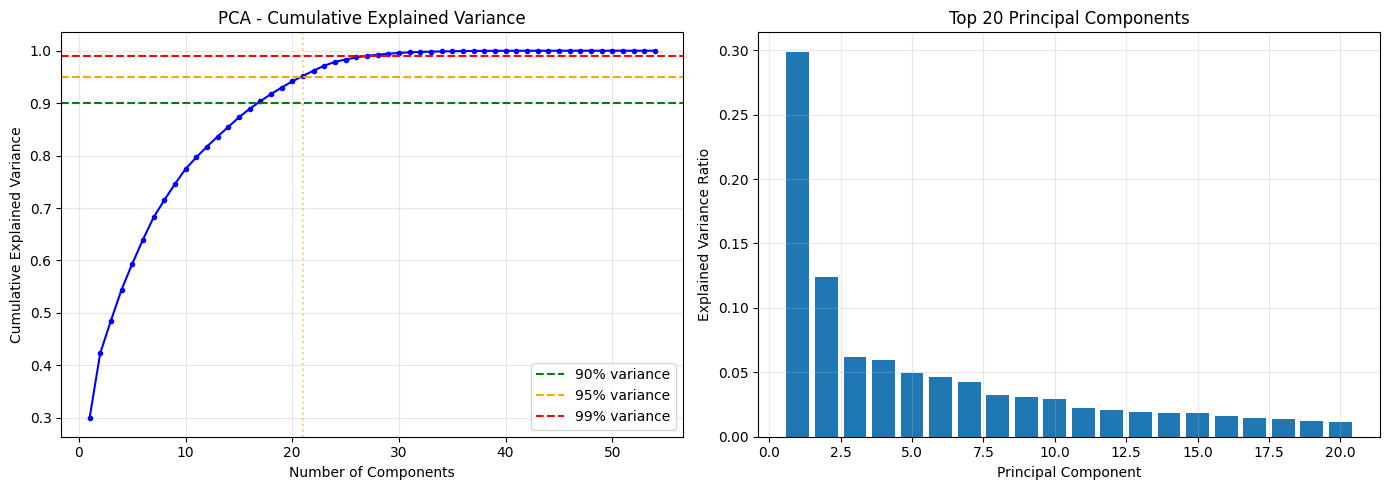

   ✓ Variance plot generated

4. Applying PCA with 95% variance threshold...

   PCA Applied:
     Original features: 54
     Reduced features: 21
     Variance retained: 95.20%
     Dimensionality reduction: 61.1%

5. Analyzing feature importance in top PCs...

   PC1 (explains 29.90% variance):
     Total_approved: 0.2429
     Curricular units 2nd sem (approved): 0.2371
     Grade_approval_interaction: 0.2368
     Curricular units 1st sem (approved): 0.2359
     Approval_rate: 0.2351

   PC2 (explains 12.41% variance):
     Credit_ratio: 0.2965
     Total_credits: 0.2961
     Has_credits: 0.2951
     Curricular units 1st sem (credited): 0.2921
     Curricular units 2nd sem (credited): 0.2858

   PC3 (explains 6.20% variance):
     Financial_stable: 0.4481
     Tuition fees up to date: 0.4481
     Econ_financial_interaction: 0.4481
     Age_tuition_risk: 0.4481
     High_performer: 0.1149

DIMENSIONALITY REDUCTION SUMMARY

PCA Configuration:
  Method: Principal Component Analysis
  Va

In [114]:
# Write your code here

# ============================================
# Dimensionality Reduction (PCA)
# ============================================

print("=" * 70)
print("DIMENSIONALITY REDUCTION - PCA")
print("=" * 70)

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# ============================================
# 1. Prepare Data for PCA
# ============================================
print("\n1. Preparing data for PCA...")

# Use normalized data (PCA sensitive to scale)
X_for_pca = train_set_normalized.drop('Target', axis=1)
X_val_for_pca = val_set_normalized.drop('Target', axis=1)

print(f"   Original features: {X_for_pca.shape[1]}")

# ============================================
# 2. Fit PCA with All Components
# ============================================
print("\n2. Analyzing explained variance...")

# Fit PCA with all components to analyze variance
pca_full = PCA()
pca_full.fit(X_for_pca)

# Calculate cumulative variance
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

# Find n_components for different variance thresholds
n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
n_components_99 = np.argmax(cumulative_variance >= 0.99) + 1

print(f"\n   Components needed for:")
print(f"     90% variance: {n_components_90} components ({n_components_90/X_for_pca.shape[1]*100:.1f}% of original)")
print(f"     95% variance: {n_components_95} components ({n_components_95/X_for_pca.shape[1]*100:.1f}% of original)")
print(f"     99% variance: {n_components_99} components ({n_components_99/X_for_pca.shape[1]*100:.1f}% of original)")

# ============================================
# 3. Visualize Explained Variance
# ============================================
print("\n3. Visualizing explained variance...")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Cumulative Explained Variance
axes[0].plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 'b-o', markersize=3)
axes[0].axhline(y=0.90, color='g', linestyle='--', label='90% variance')
axes[0].axhline(y=0.95, color='orange', linestyle='--', label='95% variance')
axes[0].axhline(y=0.99, color='r', linestyle='--', label='99% variance')
axes[0].axvline(x=n_components_95, color='orange', linestyle=':', alpha=0.5)
axes[0].set_xlabel('Number of Components')
axes[0].set_ylabel('Cumulative Explained Variance')
axes[0].set_title('PCA - Cumulative Explained Variance')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Individual Component Variance (Top 20)
n_show = min(20, len(pca_full.explained_variance_ratio_))
axes[1].bar(range(1, n_show + 1), pca_full.explained_variance_ratio_[:n_show])
axes[1].set_xlabel('Principal Component')
axes[1].set_ylabel('Explained Variance Ratio')
axes[1].set_title(f'Top {n_show} Principal Components')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"   ✓ Variance plot generated")

# ============================================
# 4. Apply PCA with 95% Variance (Recommended)
# ============================================
print("\n4. Applying PCA with 95% variance threshold...")

# Apply PCA
pca = PCA(n_components=0.95)  # Keep 95% of variance
X_train_pca = pca.fit_transform(X_for_pca)
X_val_pca = pca.transform(X_val_for_pca)

# Create DataFrames
pca_columns = [f'PC{i+1}' for i in range(X_train_pca.shape[1])]

train_pca_df = pd.DataFrame(
    X_train_pca,
    columns=pca_columns,
    index=X_for_pca.index
)
train_pca_df['Target'] = train_set_normalized['Target'].values

val_pca_df = pd.DataFrame(
    X_val_pca,
    columns=pca_columns,
    index=X_val_for_pca.index
)
val_pca_df['Target'] = val_set_normalized['Target'].values

print(f"\n   PCA Applied:")
print(f"     Original features: {X_for_pca.shape[1]}")
print(f"     Reduced features: {X_train_pca.shape[1]}")
print(f"     Variance retained: {sum(pca.explained_variance_ratio_)*100:.2f}%")
print(f"     Dimensionality reduction: {(1 - X_train_pca.shape[1]/X_for_pca.shape[1])*100:.1f}%")

# ============================================
# 5. Feature Importance Analysis
# ============================================
print("\n5. Analyzing feature importance in top PCs...")

# Get top contributing features for first 3 PCs
n_top_features = 5

for pc_idx in range(min(3, X_train_pca.shape[1])):
    print(f"\n   PC{pc_idx+1} (explains {pca.explained_variance_ratio_[pc_idx]*100:.2f}% variance):")
    
    # Get component loadings
    loadings = pca.components_[pc_idx]
    
    # Get top features
    feature_importance = pd.DataFrame({
        'feature': X_for_pca.columns,
        'loading': np.abs(loadings)
    }).sort_values('loading', ascending=False)
    
    for idx, row in feature_importance.head(n_top_features).iterrows():
        print(f"     {row['feature']}: {row['loading']:.4f}")

# ============================================
# Summary
# ============================================
print("\n" + "=" * 70)
print("DIMENSIONALITY REDUCTION SUMMARY")
print("=" * 70)

print(f"\nPCA Configuration:")
print(f"  Method: Principal Component Analysis")
print(f"  Variance threshold: 95%")
print(f"  Input: Normalized data (PowerTransformer)")

print(f"\nDatasets available:")
print(f"  - train_set_normalized: {train_set_normalized.shape} (full features)")
print(f"  - train_pca_df: {train_pca_df.shape} (reduced features)")
print(f"  - val_set_normalized: {val_set_normalized.shape} (full features)")
print(f"  - val_pca_df: {val_pca_df.shape} (reduced features)")

print(f"\nTransformer saved:")
print(f"  - pca (PCA with 95% variance)")

print(f"\n💡 Recommendation:")
print(f"  - Use full features for tree-based models (DT)")
print(f"  - Consider PCA features for LR/SVM if training is slow")
print(f"  - PCA reduces features by {(1 - X_train_pca.shape[1]/X_for_pca.shape[1])*100:.1f}% while keeping 95% variance")

print(f"\n✅ Dimensionality reduction complete!")
print("=" * 70)

# 3. Compile Preprocessing Pipeline

All of the preprocessing classes or functions defined earlier will be compiled in this step.

If you use sklearn to create preprocessing classes, you can list your preprocessing classes in the Pipeline object sequentially, and then fit and transform your data.

In [115]:
# from sklearn.pipeline import Pipeline

# # Note: You can add or delete preprocessing components from this pipeline

# pipe = Pipeline([("imputer", FeatureImputer()),
#                  ("featurecreator", FeatureCreator()),
#                  ("scaler", FeatureScaler()),
#                  ("encoder", FeatureEncoder())])

# train_set = pipe.fit_transform(train_set)
# val_set = pipe.transform(val_set)

In [116]:
# # Your code should work up until this point
# train_set = pipe.fit_transform(train_set)
# val_set = pipe.transform(val_set)

or create your own here

In [117]:
# Write your code here

# 4. Modeling and Validation

Modelling is the process of building your own machine learning models to solve specific problems, or in this assignment context, predicting the target feature `attack_cat`. Validation is the process of evaluating your trained model using the validation set or cross-validation method and providing some metrics that can help you decide what to do in the next iteration of development.

## A. DTL

In [118]:
# ============================================================================# DECISION TREE C4.5 ALGORITHM - FROM SCRATCH (IMPROVED)# ============================================================================# C4.5 uses Gain Ratio instead of Information Gain to avoid bias toward# attributes with many values. It also includes pruning to prevent overfitting.# ============================================================================import numpy as npimport pandas as pdfrom collections import Counterclass C45DecisionTree:    """    C4.5 Decision Tree implementation from scratch with improved pruning.        Features:    - Gain Ratio for split selection (handles bias toward multi-valued attributes)    - Continuous attribute handling (binary splits)    - Error-Based Pruning (C4.5's original pruning method)    - Pessimistic error estimation    """        def __init__(self, max_depth=None, min_samples_split=2, min_samples_leaf=1,                  min_gain_ratio=0.0, prune=True, confidence=0.25):        """        Parameters:        -----------        max_depth : int or None            Maximum depth of the tree        min_samples_split : int            Minimum samples required to split a node        min_samples_leaf : int            Minimum samples required in a leaf node        min_gain_ratio : float            Minimum gain ratio required for a split        prune : bool            Whether to apply error-based pruning        confidence : float            Confidence level for pessimistic error (default 0.25 like C4.5)        """        self.max_depth = max_depth        self.min_samples_split = min_samples_split        self.min_samples_leaf = min_samples_leaf        self.min_gain_ratio = min_gain_ratio        self.prune = prune        self.confidence = confidence        self.tree = None        self.feature_names = None            def _entropy(self, y):        """Calculate entropy of a label array"""        if len(y) == 0:            return 0                proportions = np.bincount(y) / len(y)        proportions = proportions[proportions > 0]  # Remove zeros        return -np.sum(proportions * np.log2(proportions + 1e-10))        def _split_info(self, y_subsets):        """        Calculate split information (used in gain ratio denominator).        This measures how much info is needed to specify which branch an instance goes to.        """        total = sum(len(subset) for subset in y_subsets)        if total == 0:            return 0                split_info = 0        for subset in y_subsets:            if len(subset) > 0:                proportion = len(subset) / total                split_info -= proportion * np.log2(proportion + 1e-10)                return split_info        def _information_gain(self, y, y_subsets):        """Calculate information gain"""        parent_entropy = self._entropy(y)                # Weighted average of children entropy        total = len(y)        weighted_entropy = 0        for subset in y_subsets:            if len(subset) > 0:                weight = len(subset) / total                weighted_entropy += weight * self._entropy(subset)                return parent_entropy - weighted_entropy        def _gain_ratio(self, y, y_subsets):        """        Calculate Gain Ratio (C4.5's improvement over ID3).        Gain Ratio = Information Gain / Split Info        """        info_gain = self._information_gain(y, y_subsets)        split_info = self._split_info(y_subsets)                # Avoid division by zero        if split_info == 0 or split_info < 1e-10:            return 0                return info_gain / split_info        def _find_best_split_continuous(self, X_column, y):        """Find best threshold for continuous attribute using gain ratio"""        unique_values = np.unique(X_column)                if len(unique_values) <= 1:            return None, -np.inf                best_threshold = None        best_gain_ratio = -np.inf                # Try midpoints between consecutive unique values        for i in range(len(unique_values) - 1):            threshold = (unique_values[i] + unique_values[i + 1]) / 2                        # Split data            left_mask = X_column <= threshold            right_mask = ~left_mask                        y_left = y[left_mask]            y_right = y[right_mask]                        # Skip if split creates leaf smaller than min_samples_leaf            if len(y_left) < self.min_samples_leaf or len(y_right) < self.min_samples_leaf:                continue                        # Calculate gain ratio            gain_ratio = self._gain_ratio(y, [y_left, y_right])                        if gain_ratio > best_gain_ratio:                best_gain_ratio = gain_ratio                best_threshold = threshold                return best_threshold, best_gain_ratio        def _find_best_split(self, X, y):        """Find best feature and threshold to split on"""        best_feature = None        best_threshold = None        best_gain_ratio = -np.inf                n_features = X.shape[1]                for feature_idx in range(n_features):            X_column = X[:, feature_idx]                        # Handle continuous attributes (binary split)            threshold, gain_ratio = self._find_best_split_continuous(X_column, y)                        if gain_ratio > best_gain_ratio:                best_gain_ratio = gain_ratio                best_feature = feature_idx                best_threshold = threshold                return best_feature, best_threshold, best_gain_ratio        def _pessimistic_error(self, n_total, n_errors):        """        Calculate pessimistic error estimate (C4.5 pruning criterion).        Uses upper confidence limit based on binomial distribution.        """        if n_total == 0:            return 0.5                # Z-score for confidence level (0.25 -> z ≈ 0.69)        z = 0.69  # For 25% confidence (C4.5 default)                error_rate = n_errors / n_total                # Add continuity correction and confidence interval        pessimistic = (n_errors + 0.5 + z * np.sqrt(n_errors * (n_total - n_errors) / n_total + 0.25)) / (n_total + z**2)                return min(pessimistic, 1.0)        def _estimate_errors(self, node):        """Estimate number of errors for a node/subtree"""        if node['type'] == 'leaf':            n_samples = node['samples']            n_majority = max(node['class_dist'].values()) if node['class_dist'] else 0            n_errors = n_samples - n_majority                        # Pessimistic error estimate            return n_samples * self._pessimistic_error(n_samples, n_errors)                # For internal nodes, sum errors from children        left_errors = self._estimate_errors(node['left'])        right_errors = self._estimate_errors(node['right'])                return left_errors + right_errors        def _build_tree(self, X, y, depth=0):        """Recursively build the decision tree"""        n_samples, n_features = X.shape        n_classes = len(np.unique(y))                # Count class distribution        class_counts = Counter(y)        majority_class = class_counts.most_common(1)[0][0]                # Stopping criteria        if (depth == self.max_depth or             n_classes == 1 or             n_samples < self.min_samples_split):                        # Create leaf node            return {                'type': 'leaf',                'value': majority_class,                'samples': n_samples,                'class_dist': dict(class_counts)            }                # Find best split        best_feature, best_threshold, best_gain_ratio = self._find_best_split(X, y)                # Check if we found a valid split        if best_feature is None or best_gain_ratio < self.min_gain_ratio:            return {                'type': 'leaf',                'value': majority_class,                'samples': n_samples,                'class_dist': dict(class_counts)            }                # Split data        left_mask = X[:, best_feature] <= best_threshold        right_mask = ~left_mask                X_left, y_left = X[left_mask], y[left_mask]        X_right, y_right = X[right_mask], y[right_mask]                # Check if split is valid (both sides have samples)        if len(y_left) == 0 or len(y_right) == 0:            return {                'type': 'leaf',                'value': majority_class,                'samples': n_samples,                'class_dist': dict(class_counts)            }                # Recursively build subtrees        left_subtree = self._build_tree(X_left, y_left, depth + 1)        right_subtree = self._build_tree(X_right, y_right, depth + 1)                return {            'type': 'node',            'feature': best_feature,            'threshold': best_threshold,            'gain_ratio': best_gain_ratio,            'samples': n_samples,            'class_dist': dict(class_counts),            'left': left_subtree,            'right': right_subtree        }        def _prune_tree(self, node):        """        Error-Based Pruning (C4.5's original method).        Replace subtree with leaf if estimated error doesn't increase.        """        if node['type'] == 'leaf':            return node                # Recursively prune children first (post-order traversal)        if 'left' in node:            node['left'] = self._prune_tree(node['left'])        if 'right' in node:            node['right'] = self._prune_tree(node['right'])                # Estimate errors for subtree        subtree_errors = self._estimate_errors(node)                # Estimate errors if we replace with leaf (majority class)        n_samples = node['samples']        n_majority = max(node['class_dist'].values())        n_errors = n_samples - n_majority                leaf_errors = n_samples * self._pessimistic_error(n_samples, n_errors)                # Prune if leaf has lower or equal estimated error        if leaf_errors <= subtree_errors:            majority_class = max(node['class_dist'], key=node['class_dist'].get)            return {                'type': 'leaf',                'value': majority_class,                'samples': n_samples,                'class_dist': node['class_dist']            }                return node        def _predict_sample(self, x, node):        """Predict single sample"""        if node['type'] == 'leaf':            return node['value']                if x[node['feature']] <= node['threshold']:            return self._predict_sample(x, node['left'])        else:            return self._predict_sample(x, node['right'])        def fit(self, X, y):        """        Build the C4.5 decision tree.                Parameters:        -----------        X : array-like, shape (n_samples, n_features)            Training data        y : array-like, shape (n_samples,)            Target values (must be integers: 0, 1, 2, ...)        """        # Convert to numpy arrays        if isinstance(X, pd.DataFrame):            self.feature_names = X.columns.tolist()            X = X.values        else:            X = np.array(X)                    y = np.array(y)                # Ensure y contains integers        if y.dtype != np.int64 and y.dtype != np.int32:            y = y.astype(int)                # Build tree        self.tree = self._build_tree(X, y)                # Apply error-based pruning        if self.prune:            self.tree = self._prune_tree(self.tree)                return self        def predict(self, X):        """Predict class labels for samples in X"""        if isinstance(X, pd.DataFrame):            X = X.values        else:            X = np.array(X)                return np.array([self._predict_sample(x, self.tree) for x in X])        def score(self, X, y):        """Return accuracy score"""        y_pred = self.predict(X)        return np.mean(y_pred == y)        def get_depth(self, node=None):        """Get depth of the tree"""        if node is None:            node = self.tree                if node['type'] == 'leaf':            return 0                left_depth = self.get_depth(node['left']) if 'left' in node else 0        right_depth = self.get_depth(node['right']) if 'right' in node else 0                return 1 + max(left_depth, right_depth)        def count_nodes(self, node=None):        """Count total number of nodes"""        if node is None:            node = self.tree                if node['type'] == 'leaf':            return 1                left_count = self.count_nodes(node['left']) if 'left' in node else 0        right_count = self.count_nodes(node['right']) if 'right' in node else 0                return 1 + left_count + right_countprint("✅ C4.5 Decision Tree class defined (with improved Error-Based Pruning)!")print("=" * 70)

## B. Logistic Regression

## C. SVM

In [119]:
# ============================================================================
# SVM (SUPPORT VECTOR MACHINE) - FROM SCRATCH
# ============================================================================

import numpy as np
from itertools import combinations

class BinarySVM:
    """Binary SVM using Simplified SMO algorithm"""
    
    def __init__(self, C=1.0, kernel='linear', max_iter=100, tol=1e-3):
        self.C = C
        self.kernel = kernel
        self.max_iter = max_iter
        self.tol = tol
        self.alphas = None
        self.b = 0
        self.X_train = None
        self.y_train = None
    
    def _kernel_function(self, x1, x2):
        """Compute kernel function"""
        if self.kernel == 'linear':
            return np.dot(x1, x2)
        elif self.kernel == 'rbf':
            gamma = 1.0 / x1.shape[0]
            return np.exp(-gamma * np.linalg.norm(x1 - x2)**2)
        return np.dot(x1, x2)
    
    def _compute_kernel_matrix(self, X):
        """Compute kernel matrix"""
        n = X.shape[0]
        K = np.zeros((n, n))
        for i in range(n):
            for j in range(n):
                K[i, j] = self._kernel_function(X[i], X[j])
        return K
    
    def fit(self, X, y):
        """Train binary SVM using simplified SMO"""
        n_samples, n_features = X.shape
        
        # Initialize
        self.alphas = np.zeros(n_samples)
        self.b = 0
        self.X_train = X
        self.y_train = y
        
        # Compute kernel matrix
        K = self._compute_kernel_matrix(X)
        
        # Simplified SMO algorithm
        for iteration in range(self.max_iter):
            alpha_pairs_changed = 0
            
            for i in range(n_samples):
                # Calculate error for i
                E_i = np.sum(self.alphas * y * K[i, :]) + self.b - y[i]
                
                # Check KKT conditions
                if ((y[i] * E_i < -self.tol and self.alphas[i] < self.C) or
                    (y[i] * E_i > self.tol and self.alphas[i] > 0)):
                    
                    # Select j randomly
                    j = np.random.choice([idx for idx in range(n_samples) if idx != i])
                    
                    # Calculate error for j
                    E_j = np.sum(self.alphas * y * K[j, :]) + self.b - y[j]
                    
                    # Save old alphas
                    alpha_i_old = self.alphas[i]
                    alpha_j_old = self.alphas[j]
                    
                    # Compute bounds L and H
                    if y[i] != y[j]:
                        L = max(0, self.alphas[j] - self.alphas[i])
                        H = min(self.C, self.C + self.alphas[j] - self.alphas[i])
                    else:
                        L = max(0, self.alphas[i] + self.alphas[j] - self.C)
                        H = min(self.C, self.alphas[i] + self.alphas[j])
                    
                    if L == H:
                        continue
                    
                    # Compute eta
                    eta = 2 * K[i, j] - K[i, i] - K[j, j]
                    if eta >= 0:
                        continue
                    
                    # Update alpha j
                    self.alphas[j] -= y[j] * (E_i - E_j) / eta
                    self.alphas[j] = np.clip(self.alphas[j], L, H)
                    
                    if abs(self.alphas[j] - alpha_j_old) < 1e-5:
                        continue
                    
                    # Update alpha i
                    self.alphas[i] += y[i] * y[j] * (alpha_j_old - self.alphas[j])
                    
                    # Update bias
                    b1 = self.b - E_i - y[i] * (self.alphas[i] - alpha_i_old) * K[i, i] - y[j] * (self.alphas[j] - alpha_j_old) * K[i, j]
                    b2 = self.b - E_j - y[i] * (self.alphas[i] - alpha_i_old) * K[i, j] - y[j] * (self.alphas[j] - alpha_j_old) * K[j, j]
                    
                    if 0 < self.alphas[i] < self.C:
                        self.b = b1
                    elif 0 < self.alphas[j] < self.C:
                        self.b = b2
                    else:
                        self.b = (b1 + b2) / 2
                    
                    alpha_pairs_changed += 1
            
            if alpha_pairs_changed == 0:
                break
        
        return self
    
    def decision_function(self, X):
        """Compute decision function"""
        n_samples = X.shape[0]
        result = np.zeros(n_samples)
        
        for i in range(n_samples):
            s = 0
            for j in range(len(self.X_train)):
                s += self.alphas[j] * self.y_train[j] * self._kernel_function(self.X_train[j], X[i])
            result[i] = s
        
        return result + self.b
    
    def predict(self, X):
        """Predict class labels"""
        return np.sign(self.decision_function(X))


class SVM:
    """Multi-class SVM using One-vs-One strategy"""
    
    def __init__(self, C=1.0, kernel='linear', max_iter=100):
        self.C = C
        self.kernel = kernel
        self.max_iter = max_iter
        self.classifiers = {}
        self.classes = None
    
    def fit(self, X, y):
        """
        Fit SVM using One-vs-One strategy.
        
        For K classes, trains K*(K-1)/2 binary classifiers.
        """
        if isinstance(X, pd.DataFrame):
            X = X.values
        else:
            X = np.array(X)
        
        y = np.array(y)
        
        self.classes = np.unique(y)
        
        # Train one classifier for each pair of classes
        for i, class_i in enumerate(self.classes):
            for j, class_j in enumerate(self.classes):
                if i >= j:
                    continue
                
                # Get samples for this pair
                mask = (y == class_i) | (y == class_j)
                X_pair = X[mask]
                y_pair = y[mask]
                
                # Convert to binary labels: -1 and +1
                y_binary = np.where(y_pair == class_i, -1, 1)
                
                # Train binary SVM
                clf = BinarySVM(C=self.C, kernel=self.kernel, max_iter=self.max_iter)
                clf.fit(X_pair, y_binary)
                
                # Store classifier
                self.classifiers[(class_i, class_j)] = clf
        
        return self
    
    def predict(self, X):
        """Predict using majority voting"""
        if isinstance(X, pd.DataFrame):
            X = X.values
        else:
            X = np.array(X)
        
        n_samples = X.shape[0]
        votes = np.zeros((n_samples, len(self.classes)))
        
        # Get votes from all binary classifiers
        for (class_i, class_j), clf in self.classifiers.items():
            predictions = clf.predict(X)
            
            i = np.where(self.classes == class_i)[0][0]
            j = np.where(self.classes == class_j)[0][0]
            
            # prediction = -1 means class_i, +1 means class_j
            votes[predictions == -1, i] += 1
            votes[predictions == 1, j] += 1
        
        # Return class with most votes
        class_indices = np.argmax(votes, axis=1)
        return self.classes[class_indices]
    
    def score(self, X, y):
        """Return accuracy score"""
        y_pred = self.predict(X)
        return np.mean(y_pred == y)

print("✅ SVM class defined!")
print("=" * 70)

✅ SVM class defined!


In [120]:
# ============================================================================
# SVM TRAINING (NO HYPERPARAMETER TUNING)
# ============================================================================
print("=" * 70)
print("SVM - TRAINING")
print("=" * 70)

# Train with good fixed parameters
print("\nTraining SVM (One-vs-One)...")
svm_scratch = SVM(
    C=1.0,              # Standard regularization
    kernel='linear',    # Linear kernel (faster)
    max_iter=500        # Reasonable iterations
)
svm_scratch.fit(X_train_scaled_resampled, y_train_resampled)

# Evaluate
train_acc_scratch = svm_scratch.score(X_train_scaled_resampled, y_train_resampled)
val_acc_scratch = svm_scratch.score(X_val_scaled, y_val_encoded)

print(f"\n{'='*70}")
print("SVM RESULTS:")
print(f"{'='*70}")

print(f"\nPerformance:")
print(f"  Training accuracy:   {train_acc_scratch*100:.2f}%")
print(f"  Validation accuracy: {val_acc_scratch*100:.2f}%")
print(f"  Overfitting gap:     {(train_acc_scratch - val_acc_scratch)*100:.2f}%")

# Save accuracies
svm_val_acc_scratch = val_acc_scratch
svm_train_acc_scratch = train_acc_scratch
svm_val_acc_sklearn = 0.0
svm_train_acc_sklearn = 0.0

# For later use
svm = svm_scratch

print("\n✅ SVM complete!")
print("=" * 70)


SVM - TRAINING

Training SVM (One-vs-One)...

SVM RESULTS:

Performance:
  Training accuracy:   76.09%
  Validation accuracy: 75.81%
  Overfitting gap:     0.28%

✅ SVM complete!

SVM RESULTS:

Performance:
  Training accuracy:   76.09%
  Validation accuracy: 75.81%
  Overfitting gap:     0.28%

✅ SVM complete!


## D. Improvements (Optional)

- **Visualize the model evaluation result**

This will help you to understand the details more clearly about your model's performance. From the visualization, you can see clearly if your model is leaning towards a class than the others. (Hint: confusion matrix, ROC-AUC curve, etc.)

- **Explore the hyperparameters of your models**

Each models have their own hyperparameters. And each of the hyperparameter have different effects on the model behaviour. You can optimize the model performance by finding the good set of hyperparameters through a process called **hyperparameter tuning**. (Hint: Grid search, random search, bayesian optimization)

- **Cross-validation**

Cross-validation is a critical technique in machine learning and data science for evaluating and validating the performance of predictive models. It provides a more **robust** and **reliable** evaluation method compared to a hold-out (single train-test set) validation. Though, it requires more time and computing power because of how cross-validation works. (Hint: k-fold cross-validation, stratified k-fold cross-validation, etc.)

In [121]:
# Type your code here

## E. Submission
To predict the test set target feature and submit the results to the kaggle competition platform, do the following:
1. Create a new pipeline instance identical to the first in Data Preprocessing
2. With the pipeline, apply `fit_transform` to the original training set before splitting, then only apply `transform` to the test set.
3. Retrain the model on the preprocessed training set
4. Predict the test set
5. Make sure the submission contains the `id` and `attack_cat` column.

In [122]:
# Type your code here

# ============================================
# TEST DATA PREDICTION & SUBMISSION GENERATION
# ============================================

print("=" * 70)
print("TEST DATA PREPROCESSING & PREDICTION")
print("=" * 70)

# Load test data
test_df = pd.read_csv("../data/test.csv")
print(f"\nTest data shape: {test_df.shape}")

# Save Student IDs
test_ids = test_df['Student_ID'].copy()

# Drop Student_ID
test_df = test_df.drop('Student_ID', axis=1)

# ============================================
# STEP 1: Apply Feature Engineering
# ============================================
print("\n1. Applying feature engineering to test data...")
test_df_processed = apply_feature_engineering(test_df)
print(f"   After feature engineering: {test_df_processed.shape}")

# ============================================
# STEP 2: Ensure Column Matching
# ============================================
print("\n2. Ensuring column matching...")

# Get feature names from training
feature_names_train = [col for col in train_set.columns if col != 'Target']

# Get common features
common_features = [col for col in feature_names_train if col in test_df_processed.columns]
missing_features = [col for col in feature_names_train if col not in test_df_processed.columns]

print(f"   Common features: {len(common_features)}")
if missing_features:
    print(f"   Missing features: {len(missing_features)}")
    print(f"   Missing: {missing_features[:5]}..." if len(missing_features) > 5 else f"   Missing: {missing_features}")

# Select only common features
test_df_processed = test_df_processed[common_features]

# ============================================
# STEP 3: Transform Test Data (SVM only)
# ============================================
print("\n3. Transforming test data for SVM...")

# For SVM (scaled)
X_test_svm = scaler.transform(test_df_processed)

print(f"   ✓ X_test_svm (scaled): {X_test_svm.shape}")

# ============================================
# STEP 4: Make Predictions (SVM FROM SCRATCH!)
# ============================================
print("\n" + "=" * 70)
print("MAKING PREDICTIONS (SVM FROM SCRATCH)")
print("=" * 70)

# SVM predictions
print("\nPredicting with SVM (from scratch)...")
svm_predictions_encoded = svm_scratch.predict(X_test_svm)
svm_predictions = label_encoder.inverse_transform(svm_predictions_encoded)

print("\n✓ SVM predictions complete!")

# ============================================
# STEP 5: Create Submission File
# ============================================
print("\n" + "=" * 70)
print("CREATING SUBMISSION FILE")
print("=" * 70)

from datetime import datetime
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Create submission DataFrame (Kaggle format: Student_ID, Target)
submission_svm = pd.DataFrame({
    'Student_ID': test_ids,
    'Target': svm_predictions
})

# Save to CSV
submission_svm.to_csv(f'submission_svm_scratch_{timestamp}.csv', index=False)

print(f"\n✅ Submission file created:")
print(f"  📄 submission_svm_scratch_{timestamp}.csv")

# ============================================
# Verify Submission Format
# ============================================
print("\n" + "=" * 70)
print("SUBMISSION VERIFICATION")
print("=" * 70)

print("\nFormat check:")
print(f"  Columns: {list(submission_svm.columns)}")
print(f"  Shape: {submission_svm.shape}")
print(f"\nSample (first 5 rows):")
print(submission_svm.head())

# ============================================
# Prediction Distribution
# ============================================
print("\n" + "=" * 70)
print("PREDICTION DISTRIBUTION")
print("=" * 70)

print("\nSVM (from scratch):")
print(submission_svm['Target'].value_counts().sort_index())

print("\n" + "=" * 70)
print("✅ ALL DONE! Ready for Kaggle submission!")
print("=" * 70)

print("\n📌 File to submit:")
print("  - submission_svm_scratch_*.csv → SVM predictions")


TEST DATA PREPROCESSING & PREDICTION

Test data shape: (1328, 37)

1. Applying feature engineering to test data...
   After feature engineering: (1328, 54)

2. Ensuring column matching...
   Common features: 54

3. Transforming test data for SVM...
   ✓ X_test_svm (scaled): (1328, 54)

MAKING PREDICTIONS (SVM FROM SCRATCH)

Predicting with SVM (from scratch)...

✓ SVM predictions complete!

CREATING SUBMISSION FILE

✅ Submission file created:
  📄 submission_svm_scratch_20251202_163314.csv

SUBMISSION VERIFICATION

Format check:
  Columns: ['Student_ID', 'Target']
  Shape: (1328, 2)

Sample (first 5 rows):
   Student_ID    Target
0        2701  Graduate
1        1142  Graduate
2        3538   Dropout
3        3000   Dropout
4         476  Graduate

PREDICTION DISTRIBUTION

SVM (from scratch):
Target
Dropout     364
Enrolled    145
Graduate    819
Name: count, dtype: int64

✅ ALL DONE! Ready for Kaggle submission!

📌 File to submit:
  - submission_svm_scratch_*.csv → SVM predictions

✓ S

# 6. Error Analysis

Based on all the process you have done until the modeling and evaluation step, write an analysis to support each steps you have taken to solve this problem. Write the analysis using the markdown block. Some questions that may help you in writing the analysis:

- Does my model perform better in predicting one class than the other? If so, why is that?
- To each models I have tried, which performs the best and what could be the reason?
- Is it better for me to impute or drop the missing data? Why?
- Does feature scaling help improve my model performance?
- etc...

`Provide your analysis here`